# Usability Sentiment Analysis — Themed, Full Dataset

880 reviews · 3 BI tools · 5 ISO 9241 usability themes  
GPT evaluates each review **through the lens of its assigned theme**, not generically.

In [ ]:
import json, time
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import openai
from tqdm.notebook import tqdm

client = openai.OpenAI(api_key="Enter your OpenAI API key here")

df = pd.read_excel(r"E:\Thesis-2025\Results\Userfriendliness\Merged_Reviews_With_Themes.xlsx")

# Drop the handful of reviews that fell outside the 5 themes
VALID_THEMES = {"Ease of Use", "Learnability", "Efficiency", "Visualization Clarity", "User Satisfaction"}
df = df[df["Theme"].isin(VALID_THEMES)].reset_index(drop=True)

print(f"{len(df)} reviews across {df['Source'].nunique()} tools and {df['Theme'].nunique()} themes")
print(df.groupby(["Source", "Theme"]).size().unstack(fill_value=0))

878 reviews across 3 tools and 5 themes
Theme     Ease of Use  Efficiency  Learnability  User Satisfaction  \
Source                                                               
Looker            102          43            56                 39   
Power BI           81          34            71                 50   
Tableau            97          44            37                 37   

Theme     Visualization Clarity  
Source                           
Looker                       38  
Power BI                     64  
Tableau                      85  


## Theme-Aware Sentiment Scoring

The prompt tells GPT *which usability dimension to focus on*.  
That stops it from drifting toward generic feature praise / complaints.

In [4]:
THEME_DESCRIPTIONS = {
    "Ease of Use":          "how intuitive and user-friendly the interface is for everyday tasks",
    "Learnability":         "how quickly new users can get up to speed, including onboarding friction and learning curve",
    "Efficiency":           "how fast and smoothly users can complete tasks once they know the tool",
    "Visualization Clarity":"how clear, readable and effective the charts and dashboards are",
    "User Satisfaction": "how positively users feel about the overall experience, including comfort, confidence, and fulfillment when using the tool",
}

def build_prompt(theme, review_text):
    focus = THEME_DESCRIPTIONS[theme]
    return f"""You are a usability researcher analysing BI tool reviews through the ISO 9241 lens.

The review below has been tagged with the usability theme: \"{theme}\".
That theme covers: {focus}.

Your job:
1. Read the review and extract ONLY what it says about \"{theme}\".
2. Ignore unrelated content (pricing, integrations, unrelated features).
3. Return exactly this JSON — nothing else:
{{
  "sentiment": "positive" | "neutral" | "negative",
  "score": <integer 1-10>,
  "evidence": "<one short sentence quoting or paraphrasing the key usability signal>"
}}

Score guide: 1-3 = serious usability problems, 4-5 = noticeable friction, 
6-7 = acceptable with minor issues, 8-9 = strong usability, 10 = exceptional.
If the theme is barely mentioned, score 5 and sentiment neutral.

REVIEW:
{str(review_text)[:600]}"""

In [5]:
BATCH = 20   # reviews per API call — sweet spot for quality vs. cost

def score_batch(rows):
    """rows: list of (theme, review_text) tuples. Returns list of dicts."""
    numbered = "\n\n".join(
        f"[{i}]\nTheme: {theme}\nReview: {text[:500]}"
        for i, (theme, text) in enumerate(rows)
    )
    prompt = f"""You are a usability researcher. For each numbered review below, 
evaluate ONLY the aspect covered by its assigned theme and return a JSON object
with keys: sentiment (positive/neutral/negative), score (1-10 int), evidence (str).

Return a single JSON object mapping index strings to result objects, e.g.:
{{"0": {{"sentiment": "positive", "score": 8, "evidence": "..."}}, "1": ...}}

Score guide: 1-3 = serious problems, 4-5 = noticeable friction, 
6-7 = acceptable with minor issues, 8-9 = strong usability, 10 = exceptional.
If theme barely mentioned → score 5, sentiment neutral.

REVIEWS:
{numbered}"""

    resp = client.chat.completions.create(
        model="gpt-4o",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.0,
        response_format={"type": "json_object"},
    )
    raw = json.loads(resp.choices[0].message.content)
    return [raw.get(str(i), {"sentiment": "neutral", "score": 5, "evidence": ""}) for i in range(len(rows))]


sentiments, scores, evidence = [], [], []
pairs = list(zip(df["Theme"], df["Review text"].fillna("")))

for start in tqdm(range(0, len(pairs), BATCH), desc="Scoring"):
    batch = pairs[start : start + BATCH]
    results = score_batch(batch)
    for r in results:
        sentiments.append(r.get("sentiment", "neutral"))
        scores.append(r.get("score", 5))
        evidence.append(r.get("evidence", ""))

df["sentiment"]  = sentiments
df["usability_score"] = scores
df["evidence"]   = evidence

df.to_excel("Merged_Reviews_Sentiment.xlsx", index=False)
print("Saved → Merged_Reviews_Sentiment.xlsx")
print(df[["Theme", "sentiment", "usability_score"]].describe())

Scoring:   0%|          | 0/44 [00:00<?, ?it/s]

Saved → Merged_Reviews_Sentiment.xlsx
       usability_score
count       878.000000
mean          6.946469
std           1.798417
min           2.000000
25%           5.000000
50%           8.000000
75%           8.000000
max          10.000000


## Snapshot: Score Distribution

In [6]:
print(df.groupby(["Theme", "sentiment"]).size().unstack(fill_value=0))
print()
print(df.groupby("Theme")["usability_score"].describe().round(2))

sentiment              negative  neutral  positive
Theme                                             
Ease of Use                   2       52       226
Efficiency                   10       33        78
Learnability                 43      105        16
User Satisfaction             5       13       108
Visualization Clarity         1       44       142

                       count  mean   std  min  25%  50%  75%   max
Theme                                                             
Ease of Use            280.0  7.45  1.39  3.0  7.0  8.0  8.0  10.0
Efficiency             121.0  6.97  1.92  2.0  5.0  8.0  9.0   9.0
Learnability           164.0  4.87  1.15  2.0  4.0  5.0  5.0   9.0
User Satisfaction      126.0  7.87  1.62  2.0  8.0  8.0  9.0  10.0
Visualization Clarity  187.0  7.37  1.45  4.0  7.0  8.0  8.0   9.0


## Visualisation 1 — Mean Usability Score by Theme & Tool

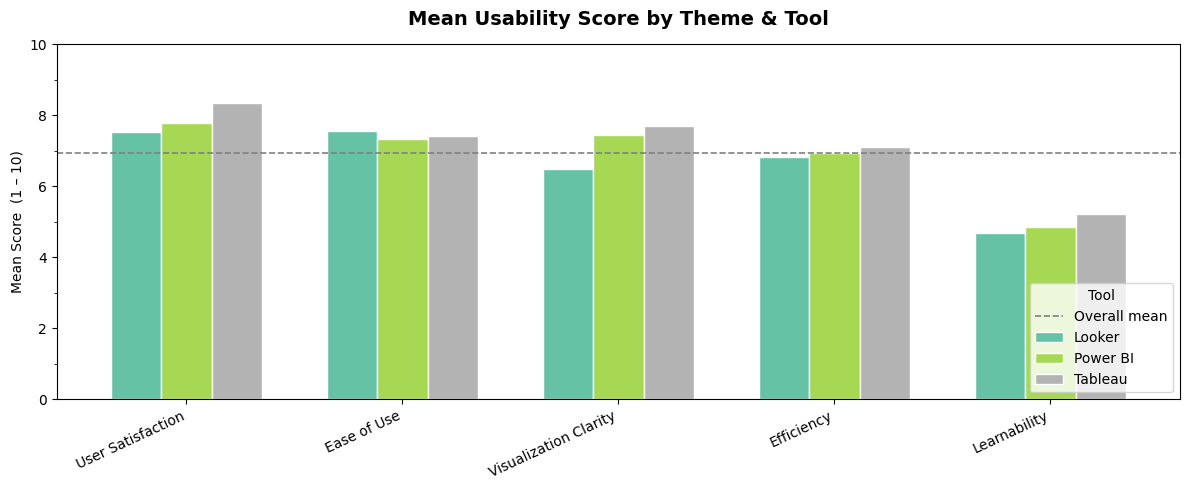

In [7]:
theme_order = (
    df.groupby("Theme")["usability_score"]
      .mean()
      .sort_values(ascending=False)
      .index.tolist()
)

pivot = (
    df.groupby(["Theme", "Source"])["usability_score"]
      .mean()
      .unstack()
      .reindex(theme_order)
)

fig, ax = plt.subplots(figsize=(12, 5))
pivot.plot(kind="bar", ax=ax, width=0.7, colormap="Set2", edgecolor="white")

ax.set_title("Mean Usability Score by Theme & Tool", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("")
ax.set_ylabel("Mean Score  (1 – 10)")
ax.set_ylim(0, 10)
ax.yaxis.set_minor_locator(mticker.MultipleLocator(1))
ax.axhline(df["usability_score"].mean(), color="gray", lw=1.2, ls="--", label="Overall mean")
ax.legend(title="Tool", loc="lower right")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

In [17]:
df.groupby(["Theme", "Source"])["usability_score"].mean()

Theme                  Source  
Ease of Use            Looker      7.549020
                       Power BI    7.345679
                       Tableau     7.432990
Efficiency             Looker      6.837209
                       Power BI    6.941176
                       Tableau     7.113636
Learnability           Looker      4.678571
                       Power BI    4.845070
                       Tableau     5.216216
User Satisfaction      Looker      7.538462
                       Power BI    7.780000
                       Tableau     8.351351
Visualization Clarity  Looker      6.500000
                       Power BI    7.453125
                       Tableau     7.705882
Name: usability_score, dtype: float64

## Visualisation 2 — Sentiment Mix per Theme (Stacked %)

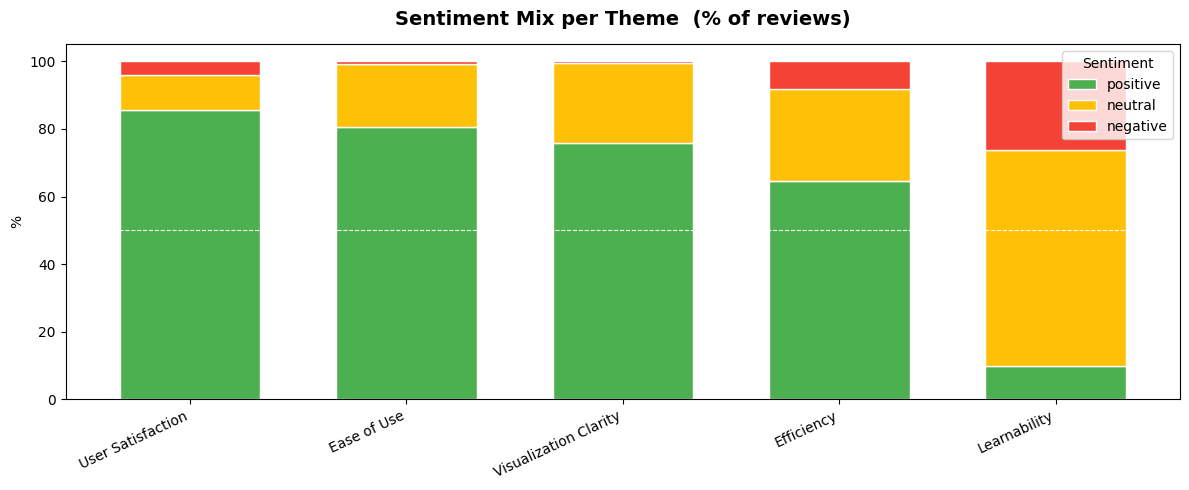

In [8]:
sent_pct = (
    df.groupby(["Theme", "sentiment"])
      .size()
      .unstack(fill_value=0)
      .reindex(theme_order)
)
sent_pct = sent_pct.div(sent_pct.sum(axis=1), axis=0) * 100

# Consistent colour mapping regardless of which sentiments are present
colour_map = {"positive": "#4CAF50", "neutral": "#FFC107", "negative": "#F44336"}
cols = [c for c in ["positive", "neutral", "negative"] if c in sent_pct.columns]

fig, ax = plt.subplots(figsize=(12, 5))
sent_pct[cols].plot(
    kind="bar", stacked=True, ax=ax, width=0.65,
    color=[colour_map[c] for c in cols], edgecolor="white"
)
ax.set_title("Sentiment Mix per Theme  (% of reviews)", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("")
ax.set_ylabel("%")
ax.set_ylim(0, 105)
ax.axhline(50, color="white", lw=0.8, ls="--")
ax.legend(title="Sentiment", loc="upper right")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## Visualisation 3 — Heatmap: Mean Score  ×  Theme  ×  Tool

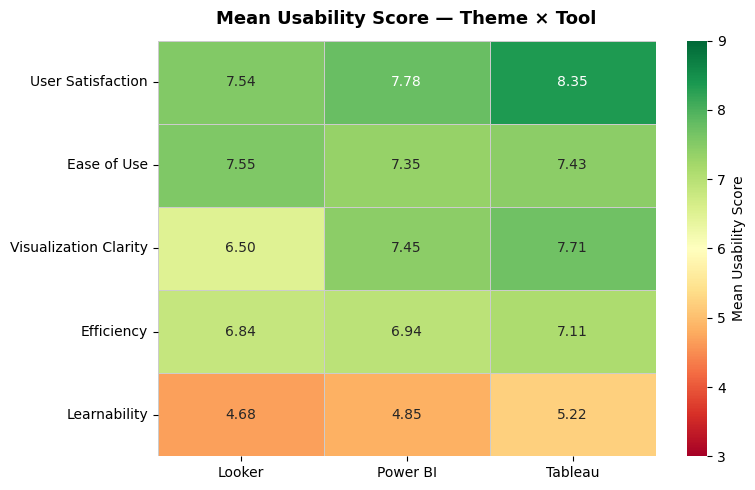

In [9]:
heat = (
    df.groupby(["Theme", "Source"])["usability_score"]
      .mean()
      .unstack()
      .reindex(theme_order)
      .round(2)
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    heat, annot=True, fmt=".2f", cmap="RdYlGn",
    vmin=3, vmax=9, center=6,
    linewidths=0.5, linecolor="#cccccc",
    cbar_kws={"label": "Mean Usability Score"},
    ax=ax
)
ax.set_title("Mean Usability Score — Theme × Tool", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Visualisation 4 — Score Distributions (violin)

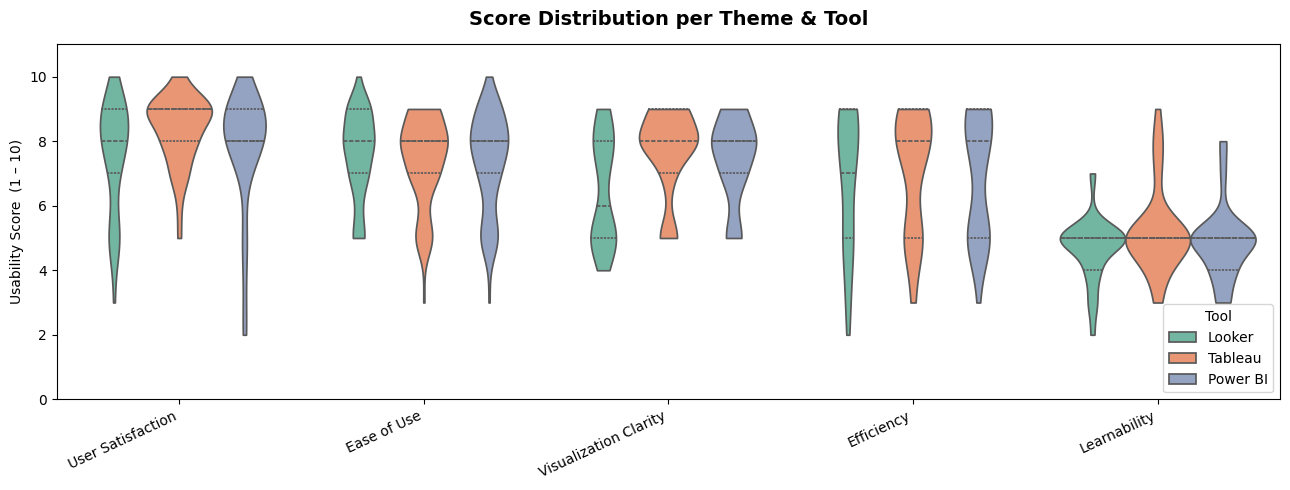

In [10]:
fig, ax = plt.subplots(figsize=(13, 5))
sns.violinplot(
    data=df, x="Theme", y="usability_score", hue="Source",
    order=theme_order, inner="quartile",
    palette="Set2", cut=0, ax=ax
)
ax.set_title("Score Distribution per Theme & Tool", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("")
ax.set_ylabel("Usability Score  (1 – 10)")
ax.set_ylim(0, 11)
ax.legend(title="Tool", loc="lower right")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()